In [1]:
# imports
# imports
from src.helpers.gromacs import *
import os
import numpy as np
import matplotlib.pyplot as plt
import warnings
import nglview as nv


Helper functions loaded.


In [2]:
# Mapping of accessions
mapping={'psychrophiles': ['YCB25778', 'UFK27161', 'YCQ78089'],
 'thermophiles': ['YP_874025', 'YP_004782219', 'AHZ95250'],
 'mesophiles': ['XCZ64124', 'WAX22921', 'UUV43823'],
 'hottest': ['YP_009791320', 'YP_004322308', 'XYR95885'],
 'coldest': ['XQO94789', 'YP_009151072', 'YP_007010273'],
 'random': ['YP_009213881', 'UVK61175', 'CAD5240622']}

accs=[item for sublist in mapping.values() for item in sublist]

In [3]:
# set protein
acc='UFK27161'

In [9]:
# Visualise original structure
pdb=f'../../../../structures/{acc.lower()}/{acc.lower()}.pdb' #Structures now deleted to save space
view = nv.show_structure_file(pdb)
view


NGLWidget()

# Visualise Trajectory

In [10]:
import MDAnalysis as mda
import nglview as nv



u1 = mda.Universe(f"{acc}/psychrophilic/results/boxed.gro", f"{acc}/psychrophilic/results/md_center.xtc")
u2 = mda.Universe(f"{acc}/mesophilic/results/boxed.gro", f"{acc}/mesophilic/results/md_center.xtc")
u3 = mda.Universe(f"{acc}/thermophilic/results/boxed.gro", f"{acc}/thermophilic/results/md_center.xtc")

view = nv.NGLWidget()

c0=view.add_trajectory(u1) # psychrophilic
c1=view.add_trajectory(u2) # mesophilic
c2=view.add_trajectory(u3) # thermophilic

# Clear and style each component separately
# IMPORTANT: clear per component, not globally ambiguous
view.clear_representations(component=0)
view.clear_representations(component=1)
view.clear_representations(component=2)


view.add_cartoon("protein", component=0, color="blue")
view.add_cartoon("protein", component=1, color="green")
view.add_cartoon("protein", component=2, color="red")

#offset each protein so they dont overlap
c0.set_position([75, 100, 0])
c1.set_position([0, 100, 0])
c2.set_position([-75, 100, 0])


view.center()
view

NGLWidget(max_frame=2000)

# Energy Minisation


Psychrophilic
Initial Epot: -996,416 kJ/mol
Final   Epot: -1,874,609 kJ/mol
Change:       -878,193 kJ/mol

Mesophilic
Initial Epot: -990,160 kJ/mol
Final   Epot: -1,872,967 kJ/mol
Change:       -882,807 kJ/mol

Thermophilic
Initial Epot: -990,039 kJ/mol
Final   Epot: -1,873,934 kJ/mol
Change:       -883,895 kJ/mol


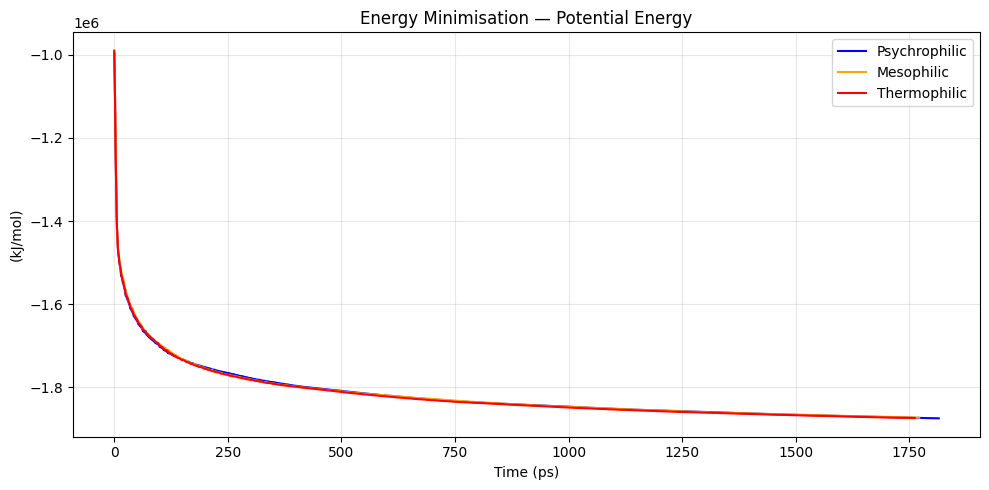

In [187]:
import matplotlib.pyplot as plt

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/potential.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/potential.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/potential.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

plt.figure(figsize=(10, 5))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    epot = d["columns"][:, 0]

    plt.plot(x, epot, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Initial Epot: {epot[0]:,.0f} kJ/mol")
    print(f"Final   Epot: {epot[-1]:,.0f} kJ/mol")
    print(f"Change:       {epot[-1] - epot[0]:,.0f} kJ/mol")

plt.title("Energy Minimisation — Potential Energy")
plt.xlabel(d["xlabel"])
plt.ylabel(d["ylabel"])

plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# NVT Equilibration - Temperature


Psychrophilic
Mean temperature: 288.0 K
Std deviation:    0.7 K

Mesophilic
Mean temperature: 310.1 K
Std deviation:    0.9 K

Thermophilic
Mean temperature: 338.6 K
Std deviation:    1.0 K


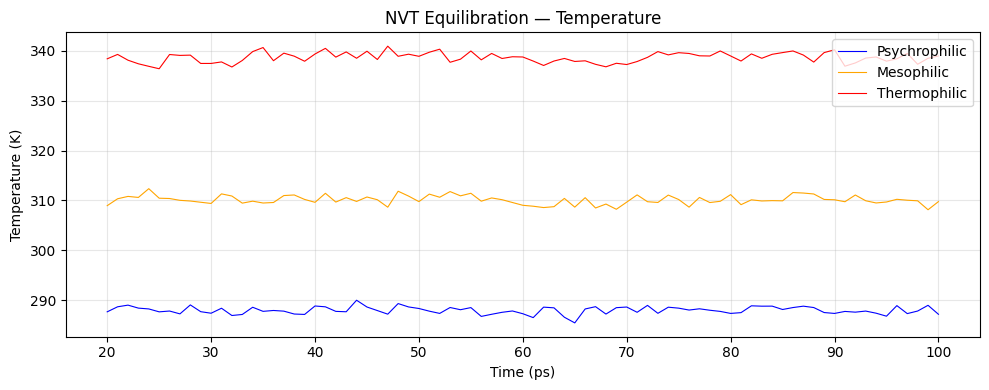

In [188]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/temperature.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/temperature.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/temperature.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    temp = d["columns"][:, 0]

    ax.plot(x, temp, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean temperature: {np.mean(temp):.1f} K")
    print(f"Std deviation:    {np.std(temp):.1f} K")


ax.set_title("NVT Equilibration — Temperature")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Temperature (K)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# NPT Equilibration - Pressure


Psychrophilic
Mean pressure:  -37.4 bar
Std deviation:  102.0 bar
RMSE from 1 bar:108.9 bar

Mesophilic
Mean pressure:  14.4 bar
Std deviation:  85.4 bar
RMSE from 1 bar:86.4 bar

Thermophilic
Mean pressure:  29.1 bar
Std deviation:  117.8 bar
RMSE from 1 bar:121.1 bar


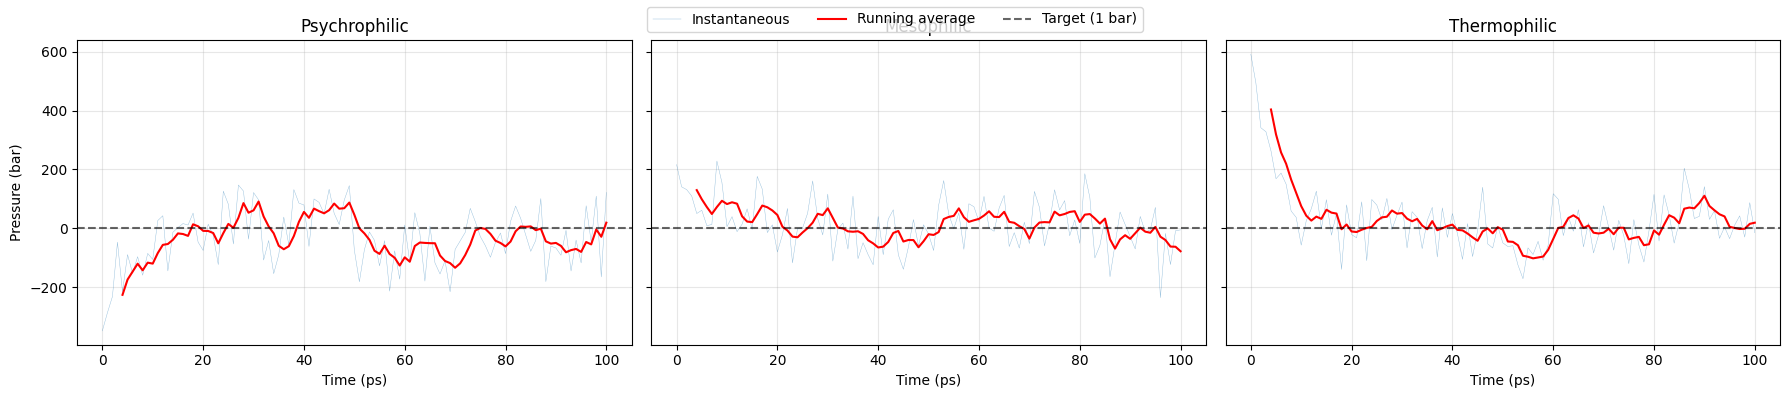

In [189]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/pressure.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/pressure.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/pressure.xvg",
}

fig, axes = plt.subplots(1, 3, figsize=(18, 4), sharey=True)

for ax, (label, file) in zip(axes, files.items()):
    d = parse_xvg(file)

    x = d["time"]
    pressure = d["columns"][:, 0]

    ax.plot(x, pressure, linewidth=0.3, alpha=0.5, label="Instantaneous")

    window = max(1, len(pressure) // 20)
    running_avg = np.convolve(pressure, np.ones(window)/window, mode="valid")

    ax.plot(
        x[window-1:],
        running_avg,
        linewidth=1.5,
        color="red",
        label="Running average"
    )

    ax.axhline(
        y=1,
        color="black",
        linestyle="--",
        alpha=0.6,
        label="Target (1 bar)"
    )

    ax.set_title(label)
    ax.set_xlabel(d["xlabel"])
    ax.grid(True, alpha=0.3)

    print(f"\n{label}")
    print(f"Mean pressure:  {np.mean(pressure):.1f} bar")
    print(f"Std deviation:  {np.std(pressure):.1f} bar")
    print(f"RMSE from 1 bar:{np.sqrt(np.mean((pressure - 1)**2)):.1f} bar")

axes[0].set_ylabel("Pressure (bar)")

# single shared legend (cleaner than repeating 3 times)
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=3)

plt.tight_layout()
plt.show()

# NPT Equilibration - Density


Psychrophilic
Mean density:  1007.7 kg/m³
Std deviation: 3.1 kg/m³

Mesophilic
Mean density:  991.1 kg/m³
Std deviation: 1.6 kg/m³

Thermophilic
Mean density:  965.3 kg/m³
Std deviation: 5.6 kg/m³


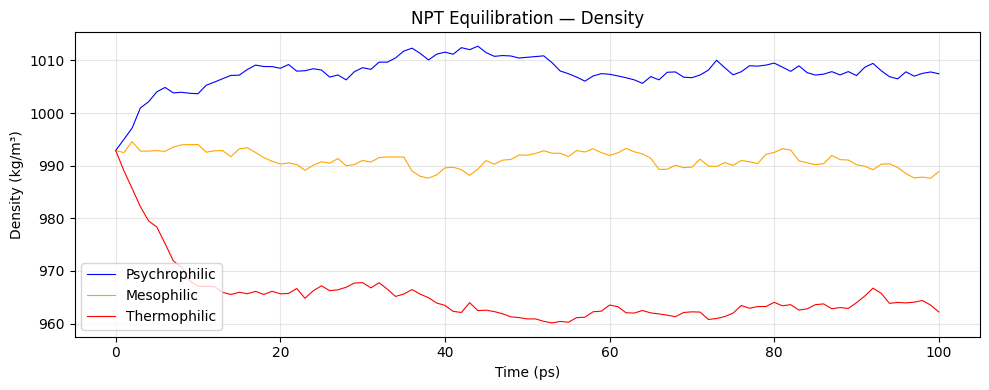

In [190]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/density.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/density.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/density.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    density = d["columns"][:, 0]

    ax.plot(x, density, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean density:  {np.mean(density):.1f} kg/m³")
    print(f"Std deviation: {np.std(density):.1f} kg/m³")

ax.set_title("NPT Equilibration — Density")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Density (kg/m³)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Minimum Image distance


Psychrophilic
Minimum distance observed: 1.289 nm
Mean distance:             2.926 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.

Mesophilic
Minimum distance observed: 2.060 nm
Mean distance:             3.326 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.

Thermophilic
Minimum distance observed: 1.609 nm
Mean distance:             3.559 nm

✓ OK: Minimum distance always exceeds 1.2 nm cutoff.


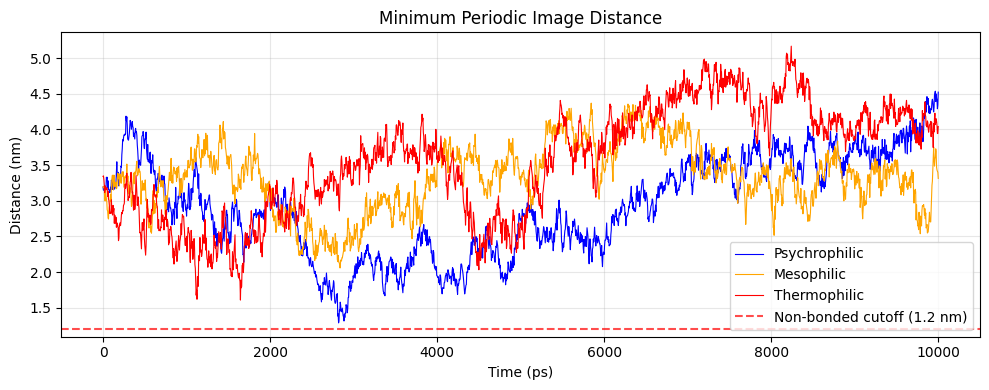

In [191]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/mindist.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/mindist.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/mindist.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    mindist = d["columns"][:, 0]

    ax.plot(x, mindist, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Minimum distance observed: {np.min(mindist):.3f} nm")
    print(f"Mean distance:             {np.mean(mindist):.3f} nm")

    if np.min(mindist) < 1.2:
        print("\n⚠️  WARNING: Distance dropped below 1.2 nm cutoff — periodic images may interact!")
        print("   Consider using a larger box (increase -d value in gmx editconf).")
    else:
        print("\n✓ OK: Minimum distance always exceeds 1.2 nm cutoff.")

# cutoff line
ax.axhline(
    y=1.2,
    color="red",
    linestyle="--",
    alpha=0.7,
    label="Non-bonded cutoff (1.2 nm)"
)

ax.set_title("Minimum Periodic Image Distance")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Distance (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# RMSD - Structural Stability


Psychrophilic
Final RMSD:         1.265 nm (12.7 Å)
Mean RMSD:          0.864 nm (8.6 Å)
Mean (last 25%):    1.210 nm (12.1 Å)

Mesophilic
Final RMSD:         1.076 nm (10.8 Å)
Mean RMSD:          0.955 nm (9.6 Å)
Mean (last 25%):    1.112 nm (11.1 Å)

Thermophilic
Final RMSD:         1.359 nm (13.6 Å)
Mean RMSD:          1.218 nm (12.2 Å)
Mean (last 25%):    1.423 nm (14.2 Å)


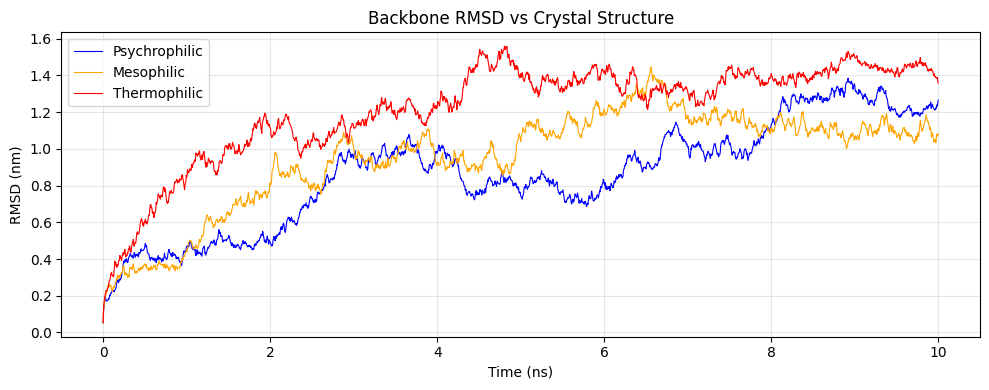

In [192]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/rmsd.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/rmsd.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/rmsd.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rmsd = d["columns"][:, 0]

    ax.plot(x, rmsd, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Final RMSD:         {rmsd[-1]:.3f} nm ({rmsd[-1]*10:.1f} Å)")
    print(f"Mean RMSD:          {np.mean(rmsd):.3f} nm ({np.mean(rmsd)*10:.1f} Å)")
    print(f"Mean (last 25%):    {np.mean(rmsd[len(rmsd)*3//4:]):.3f} nm "
          f"({np.mean(rmsd[len(rmsd)*3//4:])*10:.1f} Å)")

ax.set_title("Backbone RMSD vs Crystal Structure")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("RMSD (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'plots/{acc}_RMSD.png', dpi=300, bbox_inches='tight')
plt.show()

# Radius of Gyration


Psychrophilic
Mean Rg:            2.676 nm
Std deviation:      0.112 nm
Mean Rg (last 25%): 2.503 nm

Mesophilic
Mean Rg:            2.644 nm
Std deviation:      0.092 nm
Mean Rg (last 25%): 2.622 nm

Thermophilic
Mean Rg:            2.555 nm
Std deviation:      0.151 nm
Mean Rg (last 25%): 2.406 nm


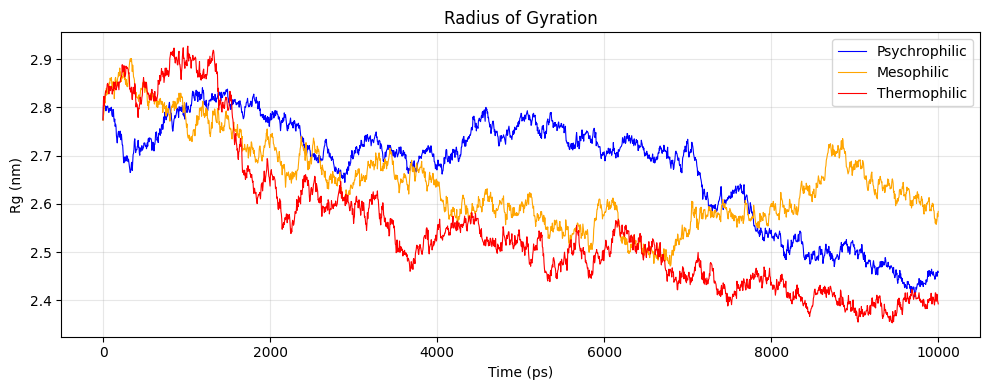

In [193]:
import matplotlib.pyplot as plt
import numpy as np

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/gyrate.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/gyrate.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/gyrate.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}


fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rg = d["columns"][:, 0]

    ax.plot(x, rg, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean Rg:            {np.mean(rg):.3f} nm")
    print(f"Std deviation:      {np.std(rg):.3f} nm")
    print(f"Mean Rg (last 25%): {np.mean(rg[len(rg)*3//4:]):.3f} nm")

ax.set_title("Radius of Gyration")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Rg (nm)")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residue Fluctuation


Psychrophilic
Mean Rmsf:            0.879 nm
Std deviation:      0.642 nm
Mean Rmsf (last 25%): 1.505 nm

Mesophilic
Mean Rmsf:            0.513 nm
Std deviation:      0.309 nm
Mean Rmsf (last 25%): 0.867 nm

Thermophilic
Mean Rmsf:            0.561 nm
Std deviation:      0.358 nm
Mean Rmsf (last 25%): 0.934 nm


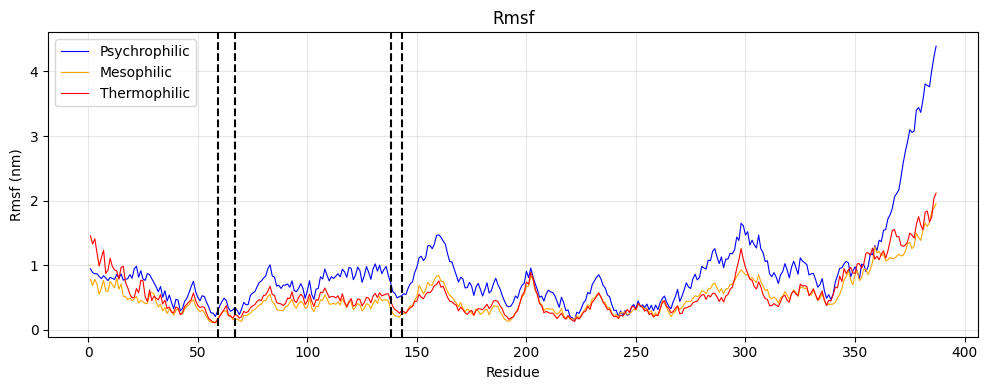

In [197]:
import matplotlib.pyplot as plt
import numpy as np
from src.biotools.fasta_tools import *

files = {
    "Psychrophilic": f"{acc}/psychrophilic/results/rmsf.xvg",
    "Mesophilic": f"{acc}/mesophilic/results/rmsf.xvg",
    "Thermophilic": f"{acc}/thermophilic/results/rmsf.xvg",
}

colors = {
    "Psychrophilic": "blue",
    "Mesophilic": "orange",
    "Thermophilic": "red",
}

# Get motifs
seq=ExtractSequence(acc, '../../../../uvsx/data/curated_database/top_hits.fasta')
walker_a=r"[GA]....[GF]K[TS]"
matches_a = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_a, seq)]
a_start=matches_a[0][0]
a_end=matches_a[0][1]

walker_b=r"[AVILMFWY]{4}DE?"
matches_b = [(m.start(),m.end(), m.group()) for m in re.finditer(walker_b, seq)]
b_start=matches_b[0][0]
b_end=matches_b[0][1]


fig, ax = plt.subplots(figsize=(10, 4))

for label, file in files.items():
    d = parse_xvg(file)

    x = d["time"]
    rmsf = d["columns"][:, 0]

    ax.plot(x, rmsf, linewidth=0.8, label=label, color=colors[label])

    print(f"\n{label}")
    print(f"Mean Rmsf:            {np.mean(rmsf):.3f} nm")
    print(f"Std deviation:      {np.std(rmsf):.3f} nm")
    print(f"Mean Rmsf (last 25%): {np.mean(rmsf[len(rmsf)*3//4:]):.3f} nm")

ax.set_title("Rmsf")
ax.set_xlabel(d["xlabel"])
ax.set_ylabel("Rmsf (nm)")


# showing walker a and b
ax.axvline(a_start, color="k", linestyle="--")
ax.axvline(a_end, color="k", linestyle="--")

ax.axvline(b_start, color="k", linestyle="--")
ax.axvline(b_end, color="k", linestyle="--")

ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f'plots/{acc}_RMSF.png', dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
mapping={'psychrophiles': ['YCB25778', 'UFK27161', 'YCQ78089'],
 'thermophiles': ['YP_874025', 'YP_004782219', 'AHZ95250'],
 'mesophiles': ['XCZ64124', 'WAX22921', 'UUV43823'],
 'hottest': ['YP_009791320', 'YP_004322308', 'XYR95885'],
 'coldest': ['XQO94789', 'YP_009151072', 'YP_007010273'],
 'random': ['YP_009213881', 'UVK61175', 'CAD5240622']}




YCB25778 - Psychrophilic
Final RMSD:         1.185 nm (11.9 Å)
Mean RMSD:          0.886 nm (8.9 Å)
Mean (last 25%):    1.281 nm (12.8 Å)

YCB25778 - Mesophilic
Final RMSD:         0.987 nm (9.9 Å)
Mean RMSD:          0.898 nm (9.0 Å)
Mean (last 25%):    1.135 nm (11.3 Å)

YCB25778 - Thermophilic
Final RMSD:         1.581 nm (15.8 Å)
Mean RMSD:          1.260 nm (12.6 Å)
Mean (last 25%):    1.585 nm (15.8 Å)

UFK27161 - Psychrophilic
Final RMSD:         1.265 nm (12.7 Å)
Mean RMSD:          0.864 nm (8.6 Å)
Mean (last 25%):    1.210 nm (12.1 Å)

UFK27161 - Mesophilic
Final RMSD:         1.076 nm (10.8 Å)
Mean RMSD:          0.955 nm (9.6 Å)
Mean (last 25%):    1.112 nm (11.1 Å)

UFK27161 - Thermophilic
Final RMSD:         1.359 nm (13.6 Å)
Mean RMSD:          1.218 nm (12.2 Å)
Mean (last 25%):    1.423 nm (14.2 Å)

YCQ78089 - Psychrophilic
Final RMSD:         1.186 nm (11.9 Å)
Mean RMSD:          1.028 nm (10.3 Å)
Mean (last 25%):    1.195 nm (12.0 Å)

YCQ78089 - Mesophilic
Final RMSD

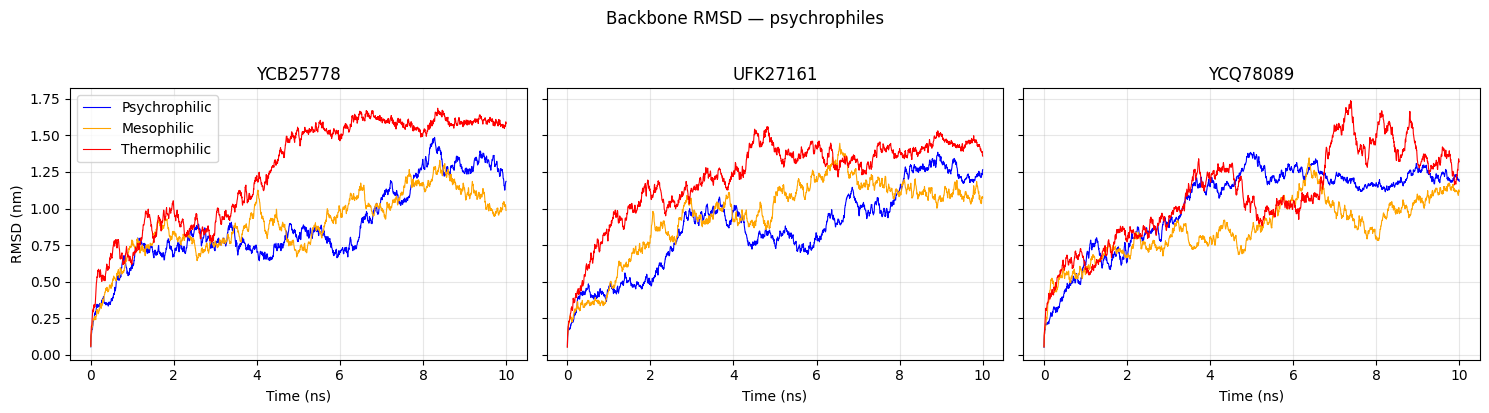


YP_874025 - Psychrophilic
Final RMSD:         0.583 nm (5.8 Å)
Mean RMSD:          0.516 nm (5.2 Å)
Mean (last 25%):    0.546 nm (5.5 Å)

YP_874025 - Mesophilic
Final RMSD:         0.804 nm (8.0 Å)
Mean RMSD:          0.653 nm (6.5 Å)
Mean (last 25%):    0.813 nm (8.1 Å)

YP_874025 - Thermophilic
Final RMSD:         0.856 nm (8.6 Å)
Mean RMSD:          0.755 nm (7.6 Å)
Mean (last 25%):    0.909 nm (9.1 Å)

YP_004782219 - Psychrophilic
Final RMSD:         0.458 nm (4.6 Å)
Mean RMSD:          0.413 nm (4.1 Å)
Mean (last 25%):    0.429 nm (4.3 Å)

YP_004782219 - Mesophilic
Final RMSD:         0.660 nm (6.6 Å)
Mean RMSD:          0.503 nm (5.0 Å)
Mean (last 25%):    0.634 nm (6.3 Å)

YP_004782219 - Thermophilic
Final RMSD:         0.767 nm (7.7 Å)
Mean RMSD:          0.647 nm (6.5 Å)
Mean (last 25%):    0.626 nm (6.3 Å)

AHZ95250 - Psychrophilic
Final RMSD:         0.494 nm (4.9 Å)
Mean RMSD:          0.446 nm (4.5 Å)
Mean (last 25%):    0.510 nm (5.1 Å)

AHZ95250 - Mesophilic
Final RMSD:

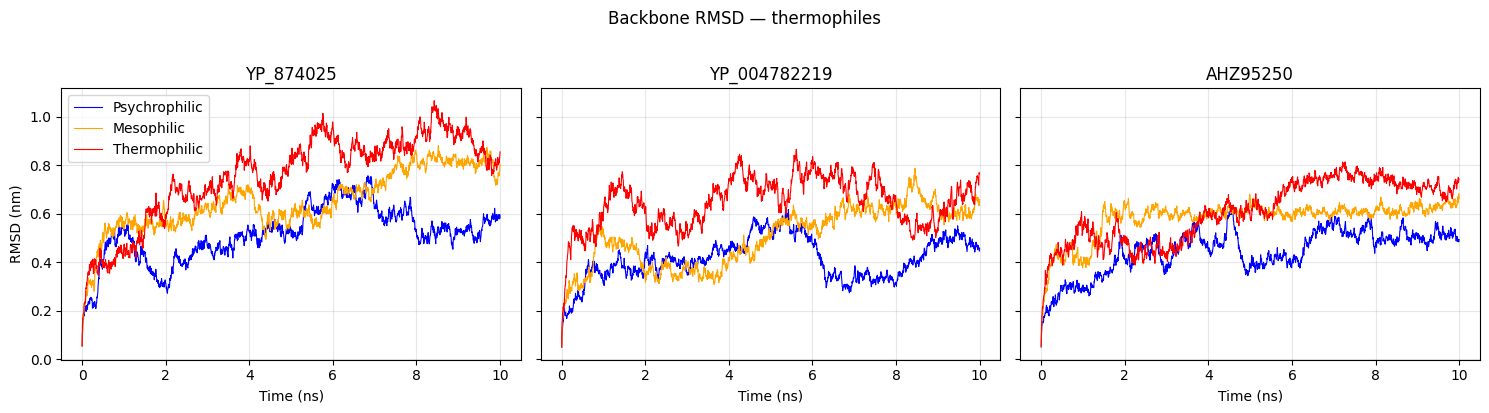


XCZ64124 - Psychrophilic
Final RMSD:         0.634 nm (6.3 Å)
Mean RMSD:          0.453 nm (4.5 Å)
Mean (last 25%):    0.564 nm (5.6 Å)

XCZ64124 - Mesophilic
Final RMSD:         0.629 nm (6.3 Å)
Mean RMSD:          0.524 nm (5.2 Å)
Mean (last 25%):    0.489 nm (4.9 Å)

XCZ64124 - Thermophilic
Final RMSD:         0.829 nm (8.3 Å)
Mean RMSD:          0.687 nm (6.9 Å)
Mean (last 25%):    0.812 nm (8.1 Å)

WAX22921 - Psychrophilic
Final RMSD:         0.307 nm (3.1 Å)
Mean RMSD:          0.315 nm (3.2 Å)
Mean (last 25%):    0.318 nm (3.2 Å)

WAX22921 - Mesophilic
Final RMSD:         0.428 nm (4.3 Å)
Mean RMSD:          0.397 nm (4.0 Å)
Mean (last 25%):    0.425 nm (4.2 Å)

WAX22921 - Thermophilic
Final RMSD:         0.403 nm (4.0 Å)
Mean RMSD:          0.386 nm (3.9 Å)
Mean (last 25%):    0.377 nm (3.8 Å)

UUV43823 - Psychrophilic
Final RMSD:         1.662 nm (16.6 Å)
Mean RMSD:          1.137 nm (11.4 Å)
Mean (last 25%):    1.632 nm (16.3 Å)

UUV43823 - Mesophilic
Final RMSD:         1.2

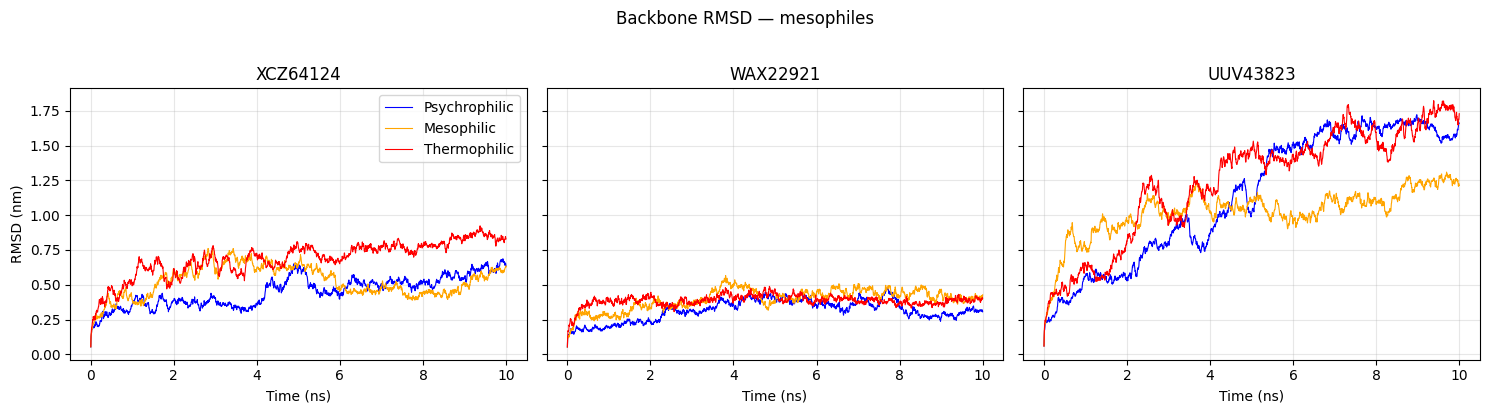


YP_009791320 - Psychrophilic
Final RMSD:         0.308 nm (3.1 Å)
Mean RMSD:          0.335 nm (3.3 Å)
Mean (last 25%):    0.334 nm (3.3 Å)

YP_009791320 - Mesophilic
Final RMSD:         0.491 nm (4.9 Å)
Mean RMSD:          0.391 nm (3.9 Å)
Mean (last 25%):    0.471 nm (4.7 Å)

YP_009791320 - Thermophilic
Final RMSD:         0.584 nm (5.8 Å)
Mean RMSD:          0.454 nm (4.5 Å)
Mean (last 25%):    0.579 nm (5.8 Å)

YP_004322308 - Psychrophilic
Final RMSD:         0.428 nm (4.3 Å)
Mean RMSD:          0.364 nm (3.6 Å)
Mean (last 25%):    0.401 nm (4.0 Å)

YP_004322308 - Mesophilic
Final RMSD:         0.490 nm (4.9 Å)
Mean RMSD:          0.438 nm (4.4 Å)
Mean (last 25%):    0.479 nm (4.8 Å)

YP_004322308 - Thermophilic
Final RMSD:         0.502 nm (5.0 Å)
Mean RMSD:          0.441 nm (4.4 Å)
Mean (last 25%):    0.474 nm (4.7 Å)

XYR95885 - Psychrophilic
Final RMSD:         0.333 nm (3.3 Å)
Mean RMSD:          0.328 nm (3.3 Å)
Mean (last 25%):    0.362 nm (3.6 Å)

XYR95885 - Mesophilic
Fi

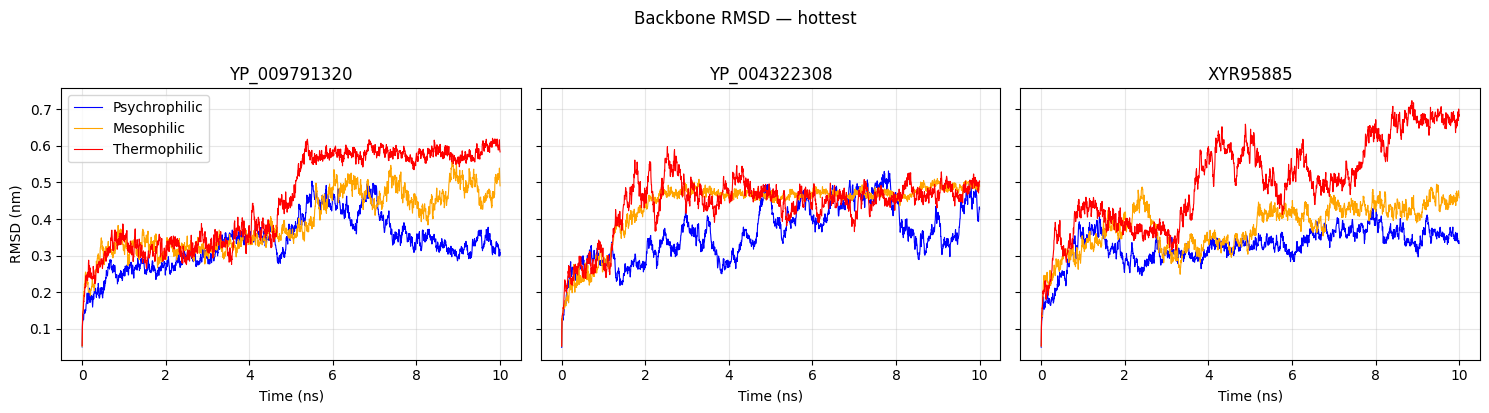


XQO94789 - Psychrophilic
Final RMSD:         0.689 nm (6.9 Å)
Mean RMSD:          0.591 nm (5.9 Å)
Mean (last 25%):    0.710 nm (7.1 Å)

XQO94789 - Mesophilic
Final RMSD:         0.560 nm (5.6 Å)
Mean RMSD:          0.517 nm (5.2 Å)
Mean (last 25%):    0.589 nm (5.9 Å)

XQO94789 - Thermophilic
Final RMSD:         0.830 nm (8.3 Å)
Mean RMSD:          0.741 nm (7.4 Å)
Mean (last 25%):    0.814 nm (8.1 Å)

YP_009151072 - Psychrophilic
Final RMSD:         0.820 nm (8.2 Å)
Mean RMSD:          0.774 nm (7.7 Å)
Mean (last 25%):    0.797 nm (8.0 Å)

YP_009151072 - Mesophilic
Final RMSD:         0.852 nm (8.5 Å)
Mean RMSD:          0.683 nm (6.8 Å)
Mean (last 25%):    0.881 nm (8.8 Å)

YP_009151072 - Thermophilic
Final RMSD:         1.071 nm (10.7 Å)
Mean RMSD:          0.824 nm (8.2 Å)
Mean (last 25%):    1.086 nm (10.9 Å)

YP_007010273 - Psychrophilic
Final RMSD:         0.581 nm (5.8 Å)
Mean RMSD:          0.536 nm (5.4 Å)
Mean (last 25%):    0.574 nm (5.7 Å)

YP_007010273 - Mesophilic
Fina

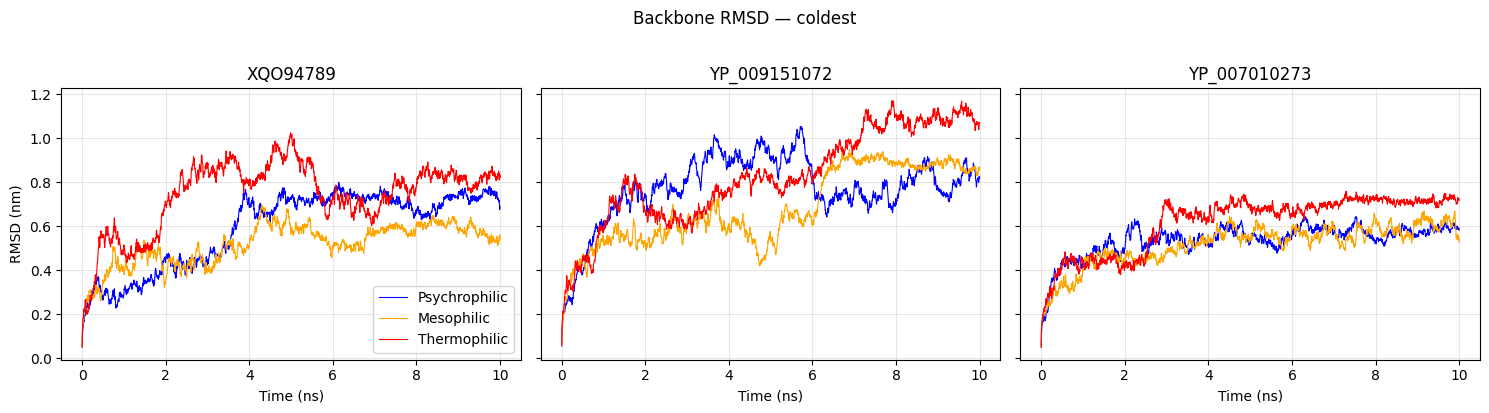


YP_009213881 - Psychrophilic
Final RMSD:         0.974 nm (9.7 Å)
Mean RMSD:          0.823 nm (8.2 Å)
Mean (last 25%):    0.943 nm (9.4 Å)

YP_009213881 - Mesophilic
Final RMSD:         1.914 nm (19.1 Å)
Mean RMSD:          1.097 nm (11.0 Å)
Mean (last 25%):    1.636 nm (16.4 Å)

YP_009213881 - Thermophilic
Final RMSD:         1.232 nm (12.3 Å)
Mean RMSD:          1.116 nm (11.2 Å)
Mean (last 25%):    1.200 nm (12.0 Å)

UVK61175 - Psychrophilic
Final RMSD:         0.620 nm (6.2 Å)
Mean RMSD:          0.552 nm (5.5 Å)
Mean (last 25%):    0.633 nm (6.3 Å)

UVK61175 - Mesophilic
Final RMSD:         0.581 nm (5.8 Å)
Mean RMSD:          0.484 nm (4.8 Å)
Mean (last 25%):    0.574 nm (5.7 Å)

UVK61175 - Thermophilic
Final RMSD:         0.642 nm (6.4 Å)
Mean RMSD:          0.607 nm (6.1 Å)
Mean (last 25%):    0.649 nm (6.5 Å)

CAD5240622 - Psychrophilic
Final RMSD:         0.606 nm (6.1 Å)
Mean RMSD:          0.502 nm (5.0 Å)
Mean (last 25%):    0.580 nm (5.8 Å)

CAD5240622 - Mesophilic
Fina

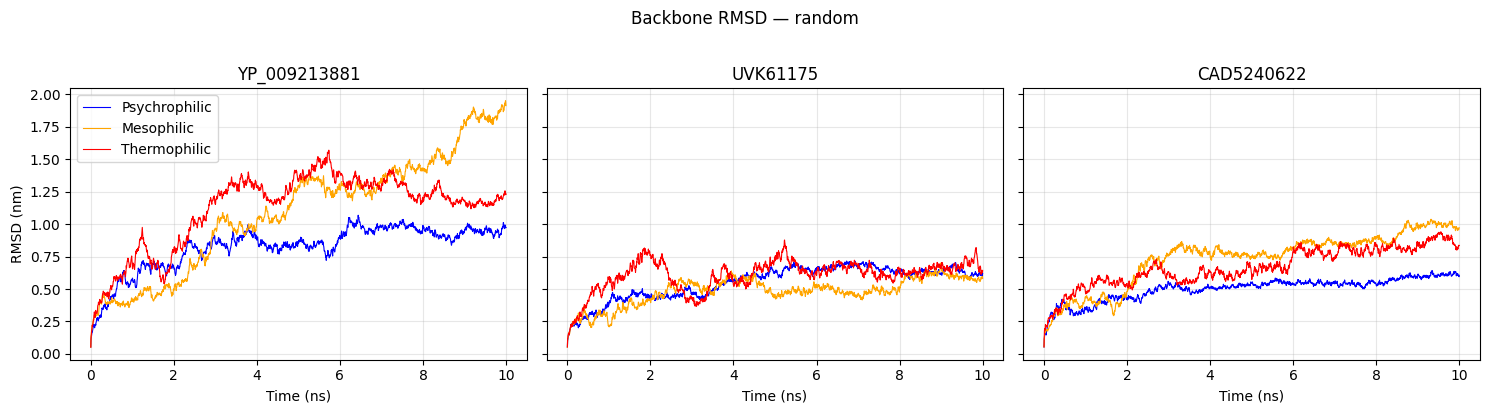

In [6]:
import matplotlib.pyplot as plt
import numpy as np

mapping = {
    'psychrophiles': ['YCB25778', 'UFK27161', 'YCQ78089'],
    'thermophiles': ['YP_874025', 'YP_004782219', 'AHZ95250'],
    'mesophiles': ['XCZ64124', 'WAX22921', 'UUV43823'],
    'hottest': ['YP_009791320', 'YP_004322308', 'XYR95885'],
    'coldest': ['XQO94789', 'YP_009151072', 'YP_007010273'],
    'random': ['YP_009213881', 'UVK61175', 'CAD5240622'],
}

for type in mapping.keys():
    accessions = mapping[type]

    colors = {
        "Psychrophilic": "blue",
        "Mesophilic": "orange",
        "Thermophilic": "red",
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, acc in zip(axes, accessions):
        files = {
            "Psychrophilic": f"{acc}/psychrophilic/results/rmsd.xvg",
            "Mesophilic": f"{acc}/mesophilic/results/rmsd.xvg",
            "Thermophilic": f"{acc}/thermophilic/results/rmsd.xvg",
        }

        for label, file in files.items():
            d = parse_xvg(file)

            x = d["time"]
            rmsd = d["columns"][:, 0]

            ax.plot(x, rmsd, linewidth=0.8, label=label, color=colors[label])

            print(f"\n{acc} - {label}")
            print(f"Final RMSD:         {rmsd[-1]:.3f} nm ({rmsd[-1]*10:.1f} Å)")
            print(f"Mean RMSD:          {np.mean(rmsd):.3f} nm ({np.mean(rmsd)*10:.1f} Å)")
            print(f"Mean (last 25%):    {np.mean(rmsd[len(rmsd)*3//4:]):.3f} nm "
                  f"({np.mean(rmsd[len(rmsd)*3//4:])*10:.1f} Å)")

        ax.set_title(acc)
        ax.set_xlabel(d["xlabel"])
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("RMSD (nm)")
    axes[0].legend()

    fig.suptitle(f"Backbone RMSD — {type}", y=1.02)

    plt.tight_layout()
    plt.savefig(f'plots/{type}_RMSD.png', dpi=300, bbox_inches='tight')
    plt.show()


YCB25778 - Psychrophilic
Mean Rmsf:            0.477 nm
Std deviation:      0.427 nm
Mean Rmsf (last 25%): 0.811 nm

YCB25778 - Mesophilic
Mean Rmsf:            0.493 nm
Std deviation:      0.406 nm
Mean Rmsf (last 25%): 0.829 nm

YCB25778 - Thermophilic
Mean Rmsf:            0.447 nm
Std deviation:      0.403 nm
Mean Rmsf (last 25%): 0.800 nm

UFK27161 - Psychrophilic
Mean Rmsf:            0.879 nm
Std deviation:      0.642 nm
Mean Rmsf (last 25%): 1.505 nm

UFK27161 - Mesophilic
Mean Rmsf:            0.513 nm
Std deviation:      0.309 nm
Mean Rmsf (last 25%): 0.867 nm

UFK27161 - Thermophilic
Mean Rmsf:            0.561 nm
Std deviation:      0.358 nm
Mean Rmsf (last 25%): 0.934 nm

YCQ78089 - Psychrophilic
Mean Rmsf:            0.467 nm
Std deviation:      0.335 nm
Mean Rmsf (last 25%): 0.715 nm

YCQ78089 - Mesophilic
Mean Rmsf:            0.567 nm
Std deviation:      0.331 nm
Mean Rmsf (last 25%): 0.849 nm

YCQ78089 - Thermophilic
Mean Rmsf:            0.895 nm
Std deviation:     

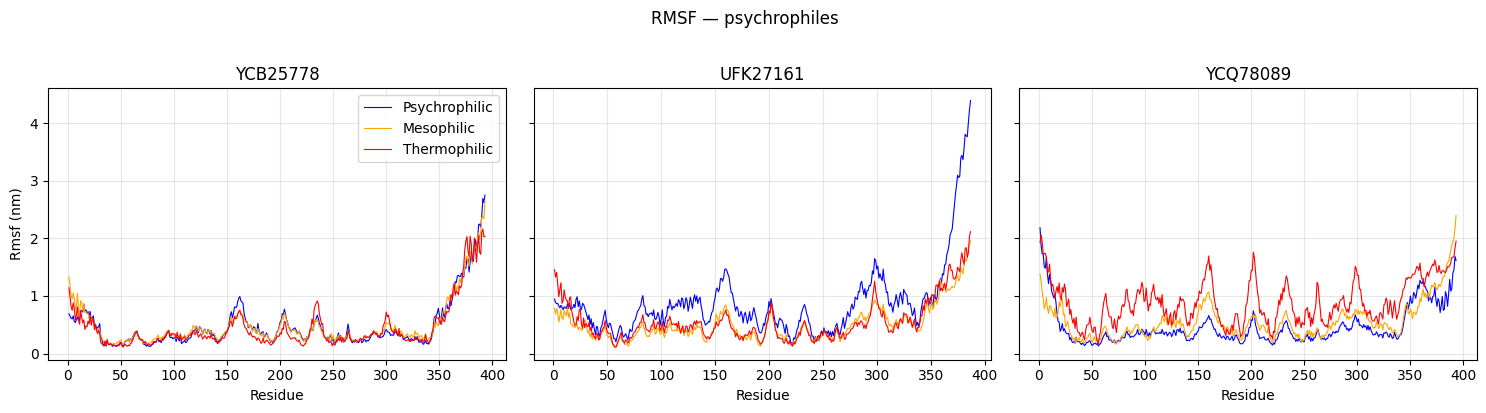


YP_874025 - Psychrophilic
Mean Rmsf:            0.241 nm
Std deviation:      0.150 nm
Mean Rmsf (last 25%): 0.276 nm

YP_874025 - Mesophilic
Mean Rmsf:            0.254 nm
Std deviation:      0.159 nm
Mean Rmsf (last 25%): 0.269 nm

YP_874025 - Thermophilic
Mean Rmsf:            0.362 nm
Std deviation:      0.257 nm
Mean Rmsf (last 25%): 0.383 nm

YP_004782219 - Psychrophilic
Mean Rmsf:            0.243 nm
Std deviation:      0.150 nm
Mean Rmsf (last 25%): 0.278 nm

YP_004782219 - Mesophilic
Mean Rmsf:            0.240 nm
Std deviation:      0.159 nm
Mean Rmsf (last 25%): 0.273 nm

YP_004782219 - Thermophilic
Mean Rmsf:            0.352 nm
Std deviation:      0.230 nm
Mean Rmsf (last 25%): 0.410 nm

AHZ95250 - Psychrophilic
Mean Rmsf:            0.277 nm
Std deviation:      0.172 nm
Mean Rmsf (last 25%): 0.367 nm

AHZ95250 - Mesophilic
Mean Rmsf:            0.244 nm
Std deviation:      0.136 nm
Mean Rmsf (last 25%): 0.293 nm

AHZ95250 - Thermophilic
Mean Rmsf:            0.318 nm
Std 

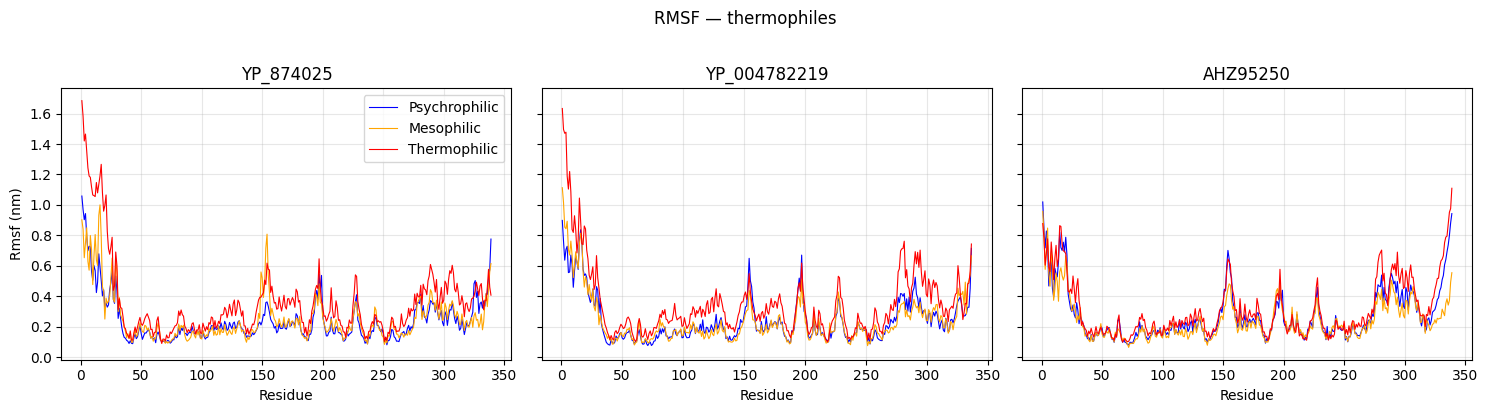


XCZ64124 - Psychrophilic
Mean Rmsf:            0.832 nm
Std deviation:      0.520 nm
Mean Rmsf (last 25%): 0.773 nm

XCZ64124 - Mesophilic
Mean Rmsf:            1.003 nm
Std deviation:      0.635 nm
Mean Rmsf (last 25%): 0.890 nm

XCZ64124 - Thermophilic
Mean Rmsf:            0.418 nm
Std deviation:      0.285 nm
Mean Rmsf (last 25%): 0.398 nm

WAX22921 - Psychrophilic
Mean Rmsf:            0.368 nm
Std deviation:      0.196 nm
Mean Rmsf (last 25%): 0.416 nm

WAX22921 - Mesophilic
Mean Rmsf:            0.270 nm
Std deviation:      0.151 nm
Mean Rmsf (last 25%): 0.291 nm

WAX22921 - Thermophilic
Mean Rmsf:            0.336 nm
Std deviation:      0.184 nm
Mean Rmsf (last 25%): 0.341 nm

UUV43823 - Psychrophilic
Mean Rmsf:            0.505 nm
Std deviation:      0.484 nm
Mean Rmsf (last 25%): 0.288 nm

UUV43823 - Mesophilic
Mean Rmsf:            0.301 nm
Std deviation:      0.325 nm
Mean Rmsf (last 25%): 0.164 nm

UUV43823 - Thermophilic
Mean Rmsf:            0.583 nm
Std deviation:     

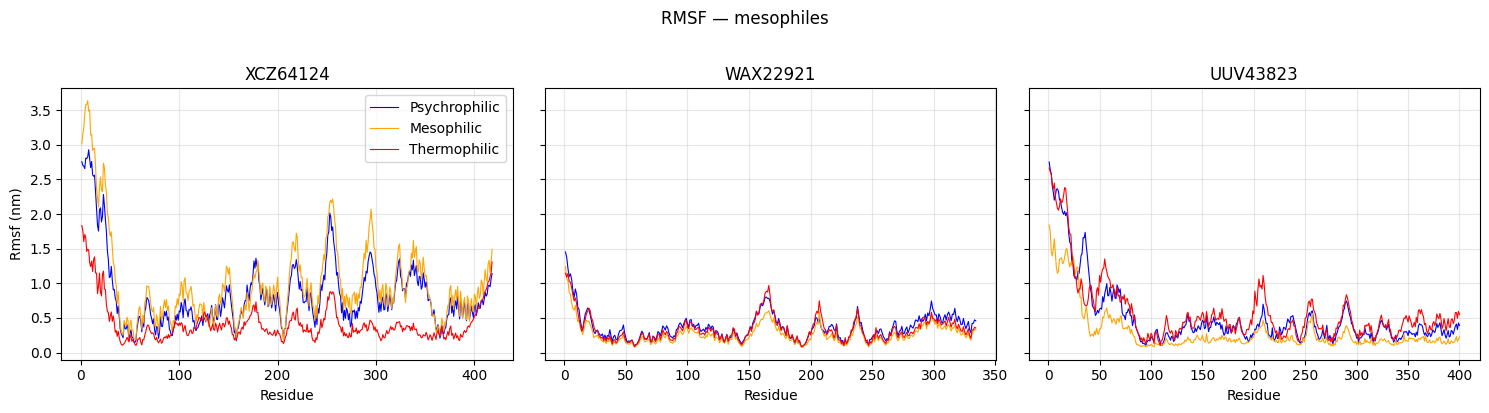


YP_009791320 - Psychrophilic
Mean Rmsf:            0.148 nm
Std deviation:      0.115 nm
Mean Rmsf (last 25%): 0.133 nm

YP_009791320 - Mesophilic
Mean Rmsf:            0.172 nm
Std deviation:      0.125 nm
Mean Rmsf (last 25%): 0.138 nm

YP_009791320 - Thermophilic
Mean Rmsf:            0.204 nm
Std deviation:      0.208 nm
Mean Rmsf (last 25%): 0.157 nm

YP_004322308 - Psychrophilic
Mean Rmsf:            0.216 nm
Std deviation:      0.141 nm
Mean Rmsf (last 25%): 0.203 nm

YP_004322308 - Mesophilic
Mean Rmsf:            0.298 nm
Std deviation:      0.141 nm
Mean Rmsf (last 25%): 0.319 nm

YP_004322308 - Thermophilic
Mean Rmsf:            0.384 nm
Std deviation:      0.194 nm
Mean Rmsf (last 25%): 0.389 nm

XYR95885 - Psychrophilic
Mean Rmsf:            0.155 nm
Std deviation:      0.101 nm
Mean Rmsf (last 25%): 0.160 nm

XYR95885 - Mesophilic
Mean Rmsf:            0.189 nm
Std deviation:      0.140 nm
Mean Rmsf (last 25%): 0.164 nm

XYR95885 - Thermophilic
Mean Rmsf:            0.20

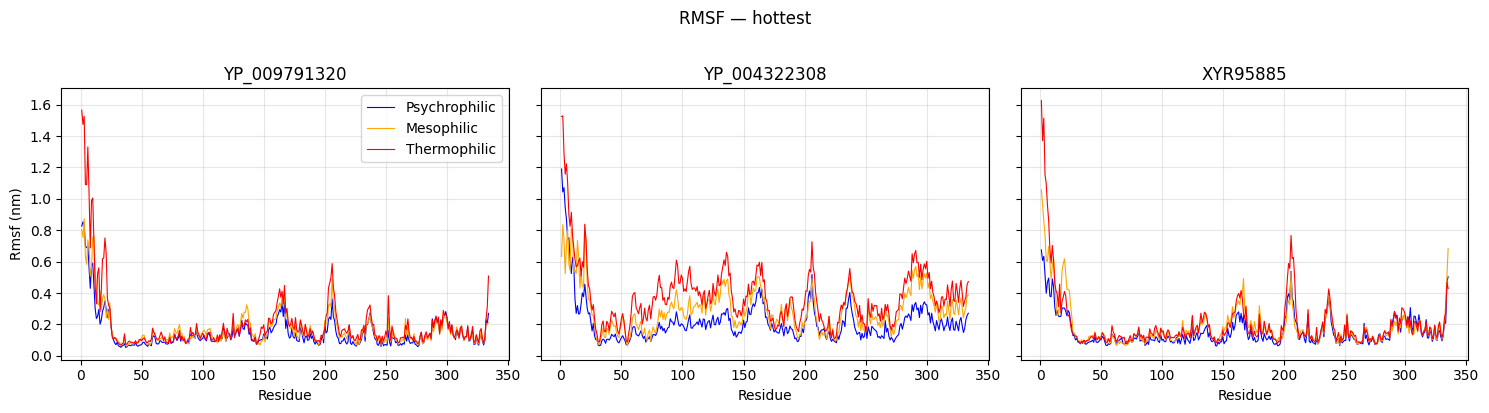


XQO94789 - Psychrophilic
Mean Rmsf:            0.243 nm
Std deviation:      0.207 nm
Mean Rmsf (last 25%): 0.337 nm

XQO94789 - Mesophilic
Mean Rmsf:            0.256 nm
Std deviation:      0.231 nm
Mean Rmsf (last 25%): 0.382 nm

XQO94789 - Thermophilic
Mean Rmsf:            0.305 nm
Std deviation:      0.269 nm
Mean Rmsf (last 25%): 0.406 nm

YP_009151072 - Psychrophilic
Mean Rmsf:            0.341 nm
Std deviation:      0.244 nm
Mean Rmsf (last 25%): 0.442 nm

YP_009151072 - Mesophilic
Mean Rmsf:            0.413 nm
Std deviation:      0.323 nm
Mean Rmsf (last 25%): 0.547 nm

YP_009151072 - Thermophilic
Mean Rmsf:            0.402 nm
Std deviation:      0.367 nm
Mean Rmsf (last 25%): 0.511 nm

YP_007010273 - Psychrophilic
Mean Rmsf:            0.255 nm
Std deviation:      0.248 nm
Mean Rmsf (last 25%): 0.383 nm

YP_007010273 - Mesophilic
Mean Rmsf:            0.231 nm
Std deviation:      0.178 nm
Mean Rmsf (last 25%): 0.285 nm

YP_007010273 - Thermophilic
Mean Rmsf:            0.24

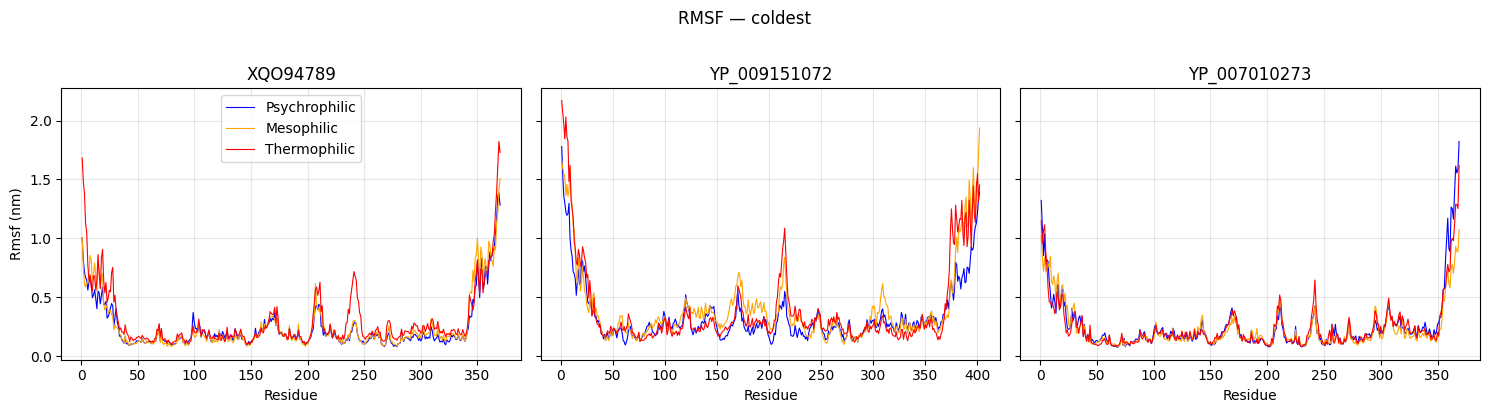


YP_009213881 - Psychrophilic
Mean Rmsf:            0.469 nm
Std deviation:      0.314 nm
Mean Rmsf (last 25%): 0.717 nm

YP_009213881 - Mesophilic
Mean Rmsf:            0.901 nm
Std deviation:      0.608 nm
Mean Rmsf (last 25%): 1.359 nm

YP_009213881 - Thermophilic
Mean Rmsf:            0.480 nm
Std deviation:      0.255 nm
Mean Rmsf (last 25%): 0.626 nm

UVK61175 - Psychrophilic
Mean Rmsf:            0.267 nm
Std deviation:      0.211 nm
Mean Rmsf (last 25%): 0.235 nm

UVK61175 - Mesophilic
Mean Rmsf:            0.352 nm
Std deviation:      0.207 nm
Mean Rmsf (last 25%): 0.353 nm

UVK61175 - Thermophilic
Mean Rmsf:            0.480 nm
Std deviation:      0.316 nm
Mean Rmsf (last 25%): 0.443 nm

CAD5240622 - Psychrophilic
Mean Rmsf:            0.197 nm
Std deviation:      0.154 nm
Mean Rmsf (last 25%): 0.257 nm

CAD5240622 - Mesophilic
Mean Rmsf:            0.294 nm
Std deviation:      0.282 nm
Mean Rmsf (last 25%): 0.443 nm

CAD5240622 - Thermophilic
Mean Rmsf:            0.288 nm
S

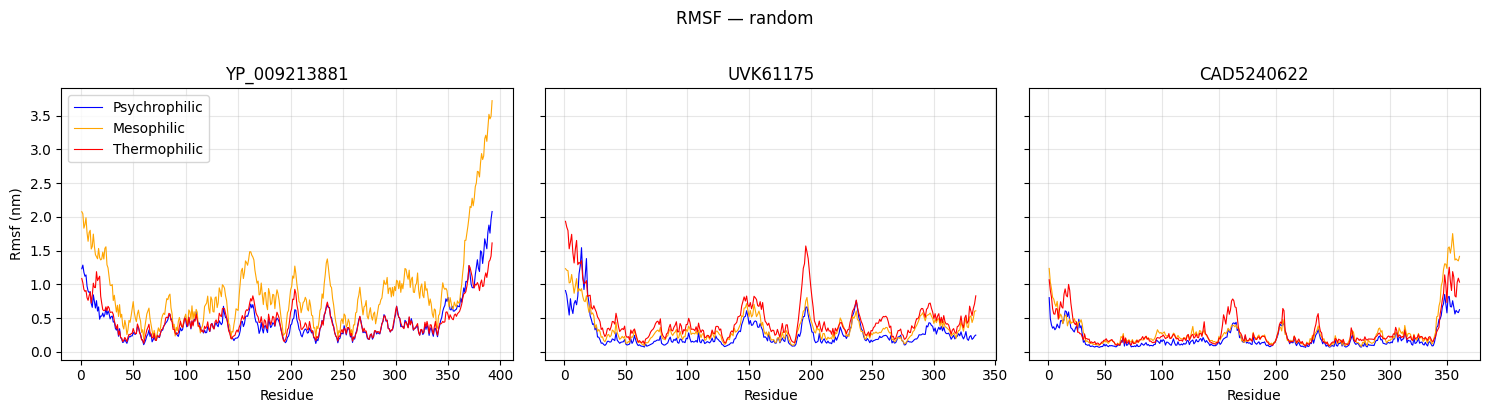

In [10]:
import matplotlib.pyplot as plt
import numpy as np
from src.biotools.fasta_tools import *

mapping = {
    'psychrophiles': ['YCB25778', 'UFK27161', 'YCQ78089'],
    'thermophiles': ['YP_874025', 'YP_004782219', 'AHZ95250'],
    'mesophiles': ['XCZ64124', 'WAX22921', 'UUV43823'],
    'hottest': ['YP_009791320', 'YP_004322308', 'XYR95885'],
    'coldest': ['XQO94789', 'YP_009151072', 'YP_007010273'],
    'random': ['YP_009213881', 'UVK61175', 'CAD5240622'],
}
for type in mapping.keys():
    accessions = mapping[type]



    colors = {
        "Psychrophilic": "blue",
        "Mesophilic": "orange",
        "Thermophilic": "red",
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, acc in zip(axes, accessions):
        files = {
            "Psychrophilic": f"{acc}/psychrophilic/results/rmsf.xvg",
            "Mesophilic": f"{acc}/mesophilic/results/rmsf.xvg",
            "Thermophilic": f"{acc}/thermophilic/results/rmsf.xvg",
        }

        # Get motifs (per-protein, since sequence differs by accession)
        seq = ExtractSequence(acc, '../../../../../3-InSilicoScreening/top_hits/sequences/top_hits.fasta')
        walker_a = r"[GA]....[GF]K[TS]"
        matches_a = [(m.start(), m.end(), m.group()) for m in re.finditer(walker_a, seq)]
        a_start = matches_a[0][0]
        a_end = matches_a[0][1]

        walker_b = r"[AVILMFWY]{4}DE?"
        matches_b = [(m.start(), m.end(), m.group()) for m in re.finditer(walker_b, seq)]
        b_start = matches_b[0][0]
        b_end = matches_b[0][1]

        for label, file in files.items():
            d = parse_xvg(file)

            x = d["time"]
            rmsf = d["columns"][:, 0]

            ax.plot(x, rmsf, linewidth=0.8, label=label, color=colors[label])

            print(f"\n{acc} - {label}")
            print(f"Mean Rmsf:            {np.mean(rmsf):.3f} nm")
            print(f"Std deviation:      {np.std(rmsf):.3f} nm")
            print(f"Mean Rmsf (last 25%): {np.mean(rmsf[len(rmsf)*3//4:]):.3f} nm")

        ax.set_title(acc)
        ax.set_xlabel(d["xlabel"])
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Rmsf (nm)")
    axes[0].legend()

    fig.suptitle(f"RMSF — {type}", y=1.02)

    plt.tight_layout()
    plt.savefig(f'plots/{type}_RMSF.png', dpi=300, bbox_inches='tight')
    plt.show()


YCB25778 - Psychrophilic
Mean Rg:            2.925 nm
Std deviation:      0.049 nm
Mean Rg (last 25%): 2.891 nm

YCB25778 - Mesophilic
Mean Rg:            2.773 nm
Std deviation:      0.160 nm
Mean Rg (last 25%): 2.587 nm

YCB25778 - Thermophilic
Mean Rg:            2.516 nm
Std deviation:      0.136 nm
Mean Rg (last 25%): 2.409 nm

UFK27161 - Psychrophilic
Mean Rg:            2.676 nm
Std deviation:      0.112 nm
Mean Rg (last 25%): 2.503 nm

UFK27161 - Mesophilic
Mean Rg:            2.644 nm
Std deviation:      0.092 nm
Mean Rg (last 25%): 2.622 nm

UFK27161 - Thermophilic
Mean Rg:            2.555 nm
Std deviation:      0.151 nm
Mean Rg (last 25%): 2.406 nm

YCQ78089 - Psychrophilic
Mean Rg:            2.732 nm
Std deviation:      0.127 nm
Mean Rg (last 25%): 2.603 nm

YCQ78089 - Mesophilic
Mean Rg:            2.685 nm
Std deviation:      0.133 nm
Mean Rg (last 25%): 2.526 nm

YCQ78089 - Thermophilic
Mean Rg:            2.742 nm
Std deviation:      0.177 nm
Mean Rg (last 25%): 2.74

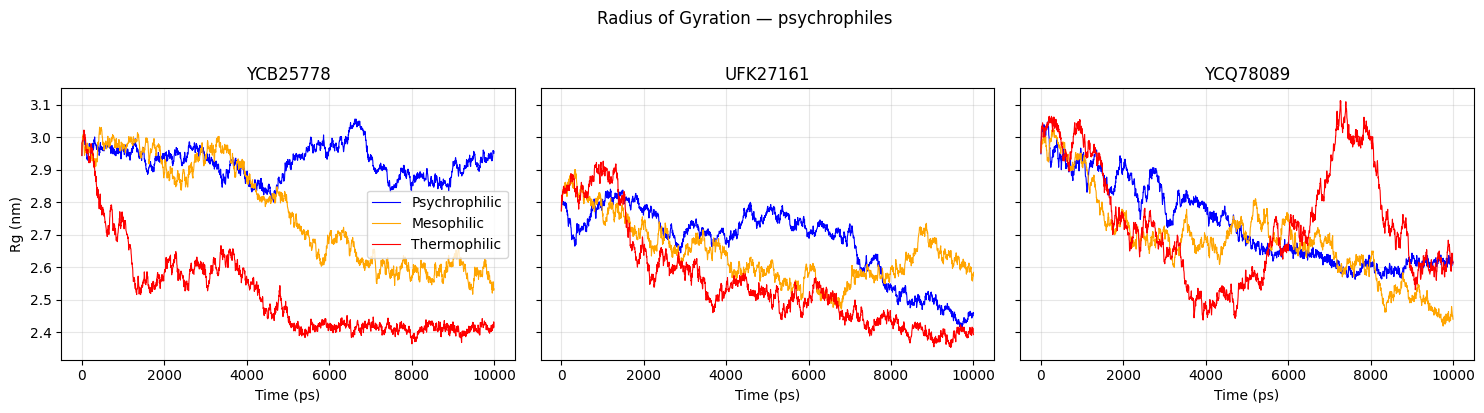


YP_874025 - Psychrophilic
Mean Rg:            2.355 nm
Std deviation:      0.020 nm
Mean Rg (last 25%): 2.363 nm

YP_874025 - Mesophilic
Mean Rg:            2.311 nm
Std deviation:      0.034 nm
Mean Rg (last 25%): 2.263 nm

YP_874025 - Thermophilic
Mean Rg:            2.370 nm
Std deviation:      0.037 nm
Mean Rg (last 25%): 2.334 nm

YP_004782219 - Psychrophilic
Mean Rg:            2.299 nm
Std deviation:      0.032 nm
Mean Rg (last 25%): 2.285 nm

YP_004782219 - Mesophilic
Mean Rg:            2.328 nm
Std deviation:      0.024 nm
Mean Rg (last 25%): 2.311 nm

YP_004782219 - Thermophilic
Mean Rg:            2.355 nm
Std deviation:      0.037 nm
Mean Rg (last 25%): 2.344 nm

AHZ95250 - Psychrophilic
Mean Rg:            2.379 nm
Std deviation:      0.023 nm
Mean Rg (last 25%): 2.356 nm

AHZ95250 - Mesophilic
Mean Rg:            2.330 nm
Std deviation:      0.031 nm
Mean Rg (last 25%): 2.295 nm

AHZ95250 - Thermophilic
Mean Rg:            2.322 nm
Std deviation:      0.054 nm
Mean Rg (

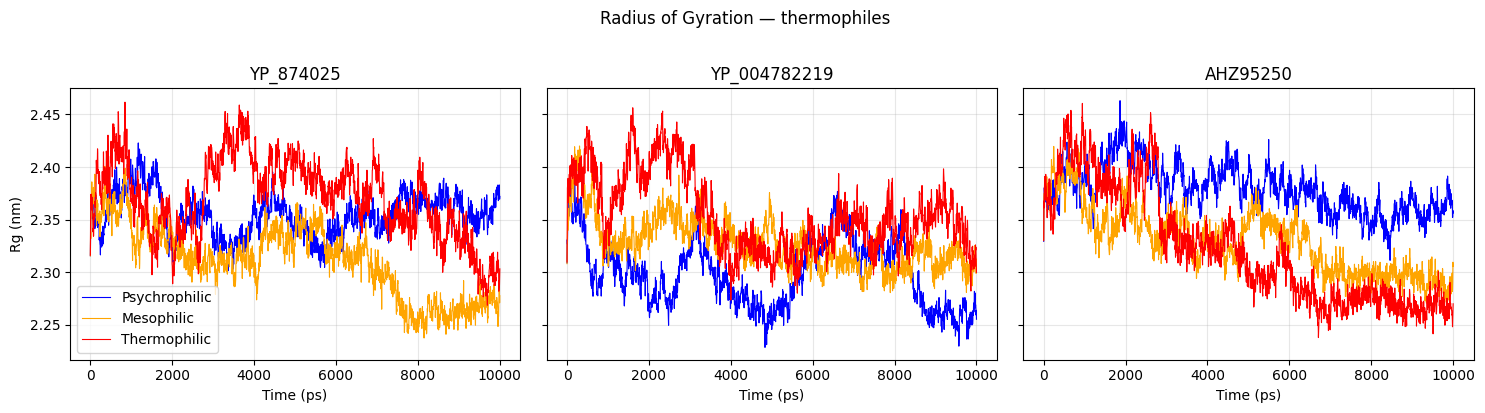


XCZ64124 - Psychrophilic
Mean Rg:            2.626 nm
Std deviation:      0.033 nm
Mean Rg (last 25%): 2.587 nm

XCZ64124 - Mesophilic
Mean Rg:            2.606 nm
Std deviation:      0.029 nm
Mean Rg (last 25%): 2.591 nm

XCZ64124 - Thermophilic
Mean Rg:            2.565 nm
Std deviation:      0.030 nm
Mean Rg (last 25%): 2.562 nm

WAX22921 - Psychrophilic
Mean Rg:            2.219 nm
Std deviation:      0.015 nm
Mean Rg (last 25%): 2.229 nm

WAX22921 - Mesophilic
Mean Rg:            2.232 nm
Std deviation:      0.014 nm
Mean Rg (last 25%): 2.238 nm

WAX22921 - Thermophilic
Mean Rg:            2.189 nm
Std deviation:      0.021 nm
Mean Rg (last 25%): 2.178 nm

UUV43823 - Psychrophilic
Mean Rg:            2.630 nm
Std deviation:      0.169 nm
Mean Rg (last 25%): 2.422 nm

UUV43823 - Mesophilic
Mean Rg:            2.595 nm
Std deviation:      0.105 nm
Mean Rg (last 25%): 2.537 nm

UUV43823 - Thermophilic
Mean Rg:            2.574 nm
Std deviation:      0.137 nm
Mean Rg (last 25%): 2.47

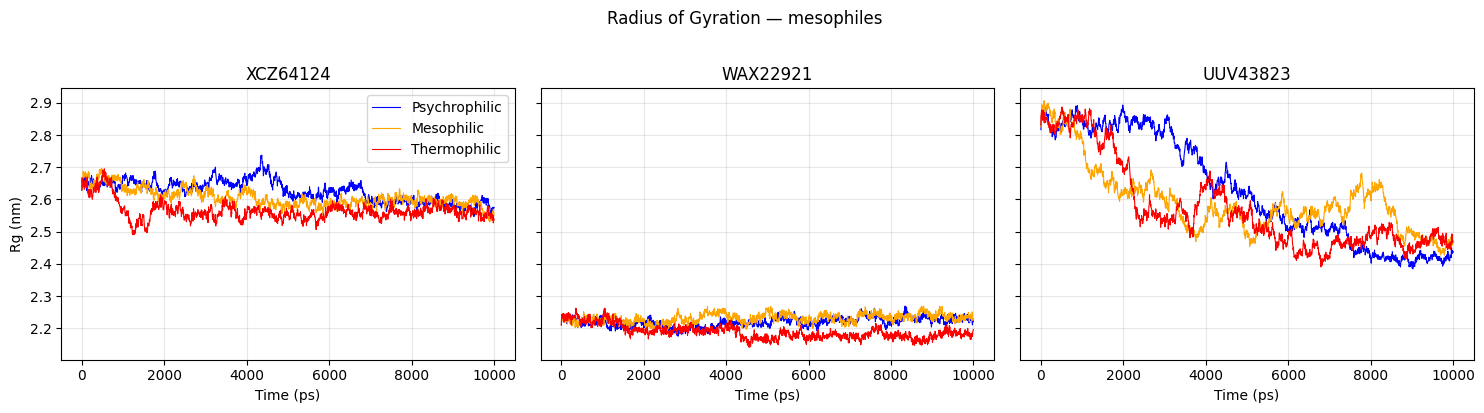


YP_009791320 - Psychrophilic
Mean Rg:            2.245 nm
Std deviation:      0.014 nm
Mean Rg (last 25%): 2.247 nm

YP_009791320 - Mesophilic
Mean Rg:            2.266 nm
Std deviation:      0.017 nm
Mean Rg (last 25%): 2.276 nm

YP_009791320 - Thermophilic
Mean Rg:            2.231 nm
Std deviation:      0.034 nm
Mean Rg (last 25%): 2.204 nm

YP_004322308 - Psychrophilic
Mean Rg:            2.238 nm
Std deviation:      0.016 nm
Mean Rg (last 25%): 2.237 nm

YP_004322308 - Mesophilic
Mean Rg:            2.168 nm
Std deviation:      0.024 nm
Mean Rg (last 25%): 2.157 nm

YP_004322308 - Thermophilic
Mean Rg:            2.232 nm
Std deviation:      0.022 nm
Mean Rg (last 25%): 2.214 nm

XYR95885 - Psychrophilic
Mean Rg:            2.265 nm
Std deviation:      0.017 nm
Mean Rg (last 25%): 2.284 nm

XYR95885 - Mesophilic
Mean Rg:            2.231 nm
Std deviation:      0.017 nm
Mean Rg (last 25%): 2.233 nm

XYR95885 - Thermophilic
Mean Rg:            2.245 nm
Std deviation:      0.030 nm


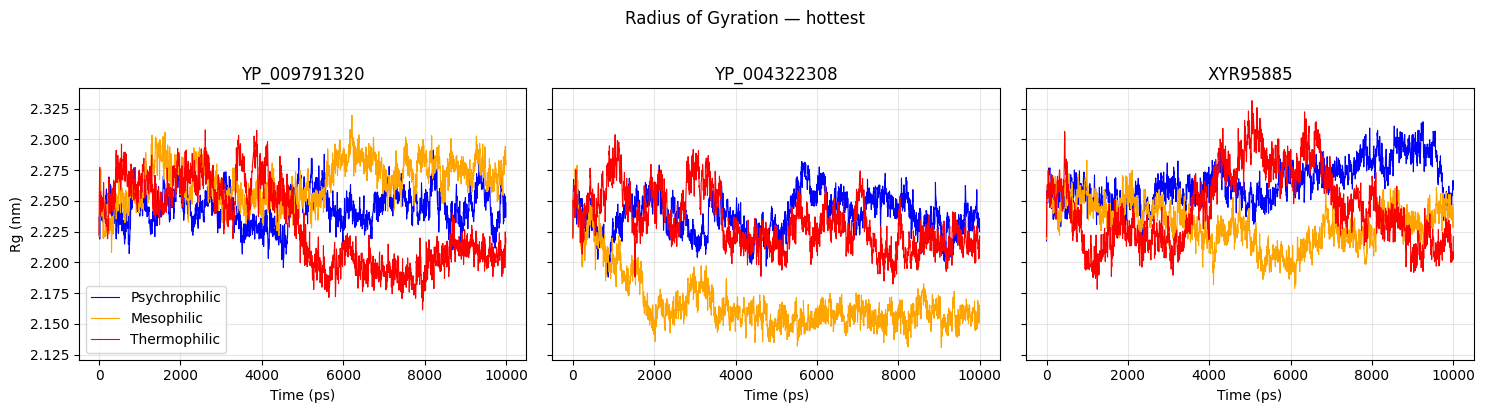


XQO94789 - Psychrophilic
Mean Rg:            2.359 nm
Std deviation:      0.068 nm
Mean Rg (last 25%): 2.318 nm

XQO94789 - Mesophilic
Mean Rg:            2.399 nm
Std deviation:      0.056 nm
Mean Rg (last 25%): 2.328 nm

XQO94789 - Thermophilic
Mean Rg:            2.354 nm
Std deviation:      0.061 nm
Mean Rg (last 25%): 2.287 nm

YP_009151072 - Psychrophilic
Mean Rg:            2.510 nm
Std deviation:      0.053 nm
Mean Rg (last 25%): 2.527 nm

YP_009151072 - Mesophilic
Mean Rg:            2.425 nm
Std deviation:      0.139 nm
Mean Rg (last 25%): 2.263 nm

YP_009151072 - Thermophilic
Mean Rg:            2.450 nm
Std deviation:      0.119 nm
Mean Rg (last 25%): 2.305 nm

YP_007010273 - Psychrophilic
Mean Rg:            2.422 nm
Std deviation:      0.057 nm
Mean Rg (last 25%): 2.370 nm

YP_007010273 - Mesophilic
Mean Rg:            2.410 nm
Std deviation:      0.037 nm
Mean Rg (last 25%): 2.391 nm

YP_007010273 - Thermophilic
Mean Rg:            2.344 nm
Std deviation:      0.060 nm


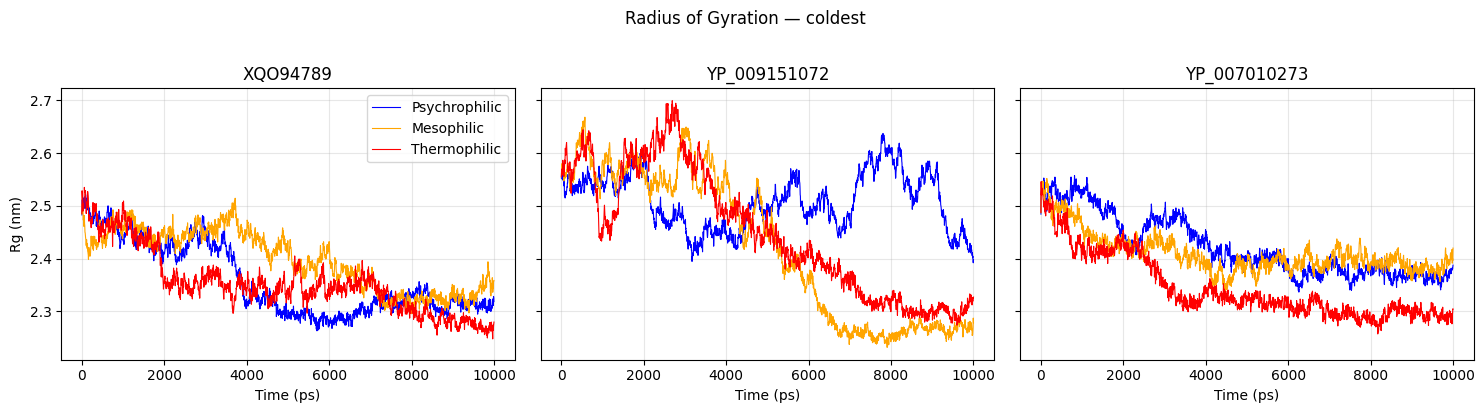


YP_009213881 - Psychrophilic
Mean Rg:            2.663 nm
Std deviation:      0.113 nm
Mean Rg (last 25%): 2.550 nm

YP_009213881 - Mesophilic
Mean Rg:            2.758 nm
Std deviation:      0.044 nm
Mean Rg (last 25%): 2.747 nm

YP_009213881 - Thermophilic
Mean Rg:            2.587 nm
Std deviation:      0.095 nm
Mean Rg (last 25%): 2.483 nm

UVK61175 - Psychrophilic
Mean Rg:            2.285 nm
Std deviation:      0.018 nm
Mean Rg (last 25%): 2.280 nm

UVK61175 - Mesophilic
Mean Rg:            2.320 nm
Std deviation:      0.046 nm
Mean Rg (last 25%): 2.272 nm

UVK61175 - Thermophilic
Mean Rg:            2.442 nm
Std deviation:      0.045 nm
Mean Rg (last 25%): 2.465 nm

CAD5240622 - Psychrophilic
Mean Rg:            2.341 nm
Std deviation:      0.042 nm
Mean Rg (last 25%): 2.318 nm

CAD5240622 - Mesophilic
Mean Rg:            2.359 nm
Std deviation:      0.062 nm
Mean Rg (last 25%): 2.298 nm

CAD5240622 - Thermophilic
Mean Rg:            2.359 nm
Std deviation:      0.032 nm
Mean R

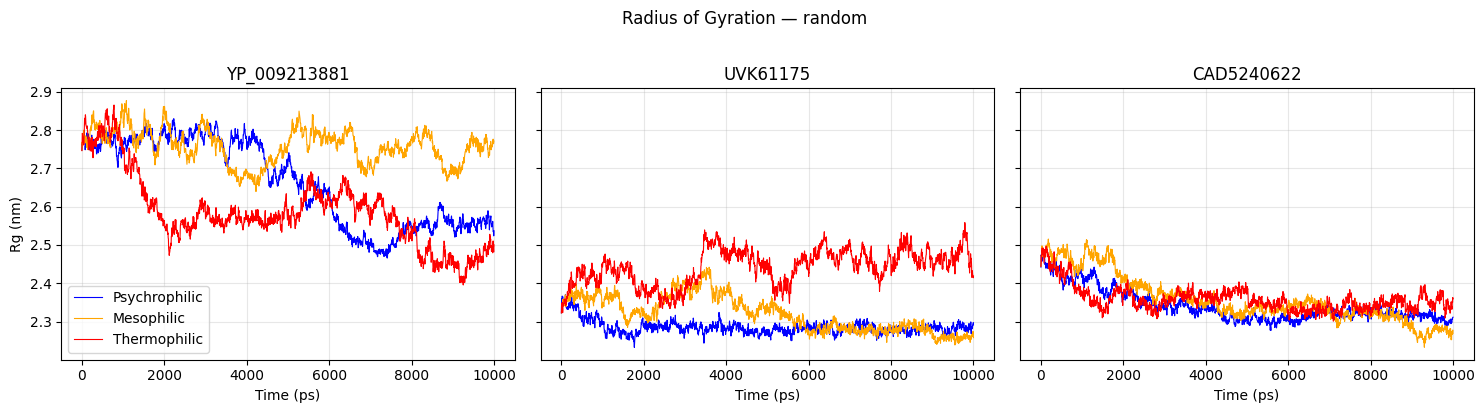

In [11]:
import matplotlib.pyplot as plt
import numpy as np

mapping = {
    'psychrophiles': ['YCB25778', 'UFK27161', 'YCQ78089'],
    'thermophiles': ['YP_874025', 'YP_004782219', 'AHZ95250'],
    'mesophiles': ['XCZ64124', 'WAX22921', 'UUV43823'],
    'hottest': ['YP_009791320', 'YP_004322308', 'XYR95885'],
    'coldest': ['XQO94789', 'YP_009151072', 'YP_007010273'],
    'random': ['YP_009213881', 'UVK61175', 'CAD5240622'],
}

for type in mapping.keys():
    accessions = mapping[type]

    colors = {
        "Psychrophilic": "blue",
        "Mesophilic": "orange",
        "Thermophilic": "red",
    }

    fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)

    for ax, acc in zip(axes, accessions):
        files = {
            "Psychrophilic": f"{acc}/psychrophilic/results/gyrate.xvg",
            "Mesophilic": f"{acc}/mesophilic/results/gyrate.xvg",
            "Thermophilic": f"{acc}/thermophilic/results/gyrate.xvg",
        }

        for label, file in files.items():
            d = parse_xvg(file)

            x = d["time"]
            rg = d["columns"][:, 0]

            ax.plot(x, rg, linewidth=0.8, label=label, color=colors[label])

            print(f"\n{acc} - {label}")
            print(f"Mean Rg:            {np.mean(rg):.3f} nm")
            print(f"Std deviation:      {np.std(rg):.3f} nm")
            print(f"Mean Rg (last 25%): {np.mean(rg[len(rg)*3//4:]):.3f} nm")

        ax.set_title(acc)
        ax.set_xlabel(d["xlabel"])
        ax.grid(True, alpha=0.3)

    axes[0].set_ylabel("Rg (nm)")
    axes[0].legend()

    fig.suptitle(f"Radius of Gyration — {type}", y=1.02)

    plt.tight_layout()
    plt.savefig(f'plots/{type}_RG.png', dpi=300, bbox_inches='tight')
    plt.show()